# Phase 5 — Tree models (Random Forest, Gradient Boosting)

Adds two non-linear models to the comparison. Unlike Ridge, trees are scale-invariant, so they use the **full** feature set including the raw ordinal time columns (`hour`, `month`, `dayofweek`, `year`) that the linear pipeline had to drop. Both are trained on `log1p(count)` with the clipped inverse, so predictions stay non-negative. Hyperparameters live in `config/models.yaml`; metrics come from `reports/metrics.json`. This notebook is diagnostic, not part of the runtime pipeline.

## Setup

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from bike_sharing.config import load_config

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "config" / "config.yaml").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError("Could not locate config/config.yaml above cwd.")
    PROJECT_ROOT = PROJECT_ROOT.parent

CFG = load_config(PROJECT_ROOT / "config" / "config.yaml")
REPORTS_DIR = Path(CFG["paths"]["reports_dir"])
FIG_DIR = REPORTS_DIR / "figures"
MODELS_DIR = Path(CFG["paths"]["models_dir"])
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(context="notebook", style="whitegrid")
metrics = json.loads((REPORTS_DIR / "metrics.json").read_text())
print("models in metrics.json:", sorted(metrics))


models in metrics.json: ['gradient_boosting', 'hourly_mean_baseline', 'mean_baseline', 'random_forest', 'ridge']


## 1. Model comparison

All four metrics on both validation views (chronological CV and the day-of-month holdout). Read them together; RMSLE is shown first because the target is right-skewed.

In [2]:
# All five models on both validation views, all four metrics.
rows = []
for name, summary in metrics.items():
    cv = summary["cv"]["mean"]
    hold = summary["day_of_month_holdout"]["metrics"]
    rows.append({
        "model": name,
        "cv_rmsle": cv["rmsle"],
        "holdout_rmsle": hold["rmsle"],
        "holdout_rmse": hold["rmse"],
        "holdout_mae": hold["mae"],
        "holdout_r2": hold["r2"],
    })
table = pd.DataFrame(rows).set_index("model").sort_values("holdout_rmsle")
table.round(3)


,cv_rmsle,holdout_rmsle,holdout_rmse,holdout_mae,holdout_r2
model,,,,,
random_forest,0.514,0.330,51.865,30.366,0.920
gradient_boosting,0.471,0.334,59.005,36.508,0.896
hourly_mean_baseline,0.739,0.755,125.884,86.065,0.527
ridge,0.987,0.905,162.224,106.179,0.214
mean_baseline,1.402,1.531,183.077,142.644,-0.001


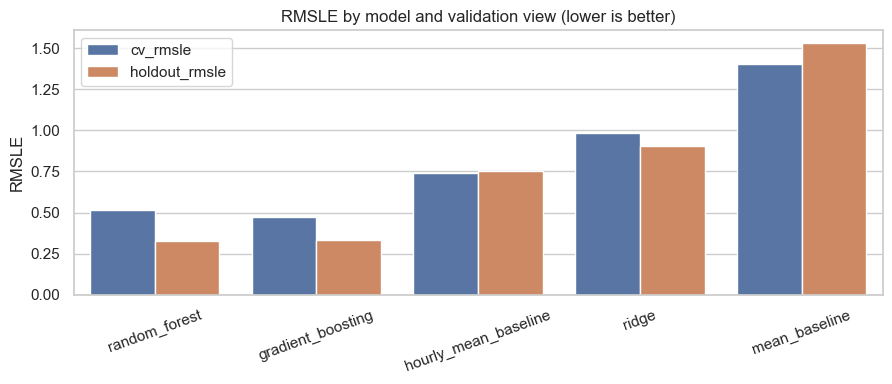

In [3]:
order = table.index.tolist()
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = (
    table[["cv_rmsle", "holdout_rmsle"]]
    .reset_index()
    .melt(id_vars="model", var_name="view", value_name="rmsle")
)
sns.barplot(data=plot_df, x="model", y="rmsle", hue="view", order=order, ax=ax)
ax.set_title("RMSLE by model and validation view (lower is better)")
ax.set_xlabel("")
ax.set_ylabel("RMSLE")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_model_comparison_rmsle.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Feature importances

Which inputs the trees actually rely on. This is the explanatory payload: it lets us connect model behavior back to the project's temporal and environmental questions rather than just reporting a score.

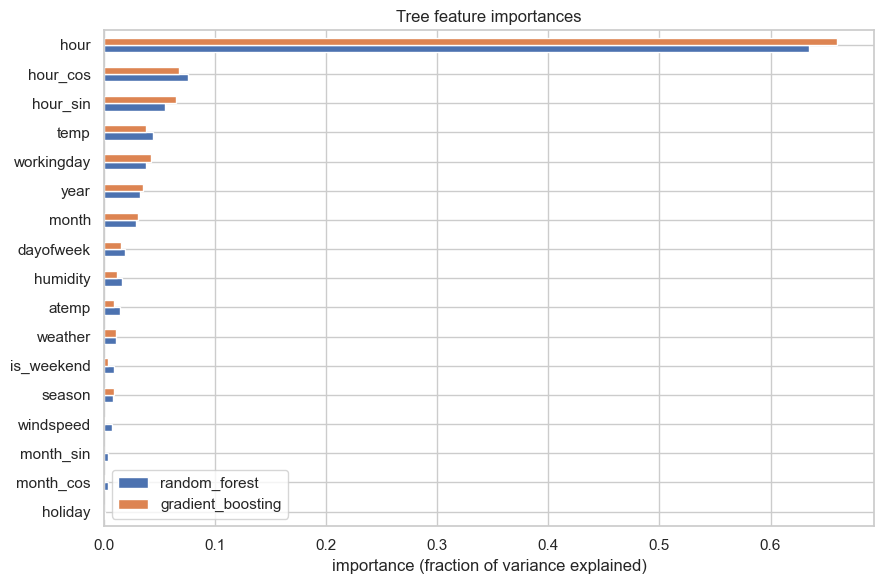

,random_forest,gradient_boosting
hour,0.635,0.660
hour_cos,0.076,0.068
hour_sin,0.055,0.065
temp,0.044,0.038
workingday,0.038,0.042
year,0.033,0.035
month,0.029,0.030
dayofweek,0.019,0.016
humidity,0.016,0.012
atemp,0.014,0.009


In [4]:
# Feature importances from the persisted tree models. The estimator is a
# TransformedTargetRegressor; the fitted tree is at `.regressor_`.
train_cols = pd.read_parquet(
    Path(CFG["paths"]["processed_dir"]) / "train.parquet"
).drop(columns=[CFG["target"], CFG["datetime_col"]]).columns.tolist()

imp = {}
for name in ("random_forest", "gradient_boosting"):
    model = joblib.load(MODELS_DIR / f"{name}.joblib")
    imp[name] = pd.Series(model.regressor_.feature_importances_, index=train_cols)

imp_df = pd.DataFrame(imp).sort_values("random_forest", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
imp_df.plot(kind="barh", ax=ax)
ax.set_title("Tree feature importances")
ax.set_xlabel("importance (fraction of variance explained)")
ax.set_ylabel("")
ax.legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "13_tree_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
imp_df.sort_values("random_forest", ascending=False).round(3)


## Findings (interpretation for the report)

- Both trees decisively beat the baselines and Ridge on every metric and both validation views. Capturing the `hour × workingday` interaction non-linearly is exactly what the linear model could not do with first-harmonic cyclic features.
- Feature importance is dominated by the **temporal** signal — `hour` (and its cyclic encodings) plus `workingday`/`year` — confirming the EDA story that time-of-day drives demand. This directly answers the proposal's temporal-pattern question.
- **Environmental** inputs (`temp`/`atemp`, `humidity`, `weather`, `season`) form the next tier: real but secondary. That is the environmental-impact narrative — weather modulates demand around the dominant daily rhythm rather than setting it.
- The two validation views agree on the ranking, and the day-of-month holdout R² (~0.90) shows the trees generalize to the later days of each month, the harder split.
- Phase 6 will try XGBoost as an optional stronger model and produce the test-set `datetime,count` prediction artifact; Phase 7 consolidates these results and interpretations into the written report. Any hyperparameter tuning beyond the current `config/models.yaml` defaults would be a `docs/experiments/` plan, per AGENTS.md §7.